# V2 Prediction Model

This notebook trains and evaluates supervised temperature prediction models from the v2 object timeline dataset.

The notebook uses the same prepared feature table for LightGBM and XGBoost, compares baseline and tuned settings, and exports tuned test-set prediction CSV files for downstream use.


## Setup

This section imports the project configuration, model helper functions, plotting libraries, and optimization package.

| Item | Purpose |
|---|---|
| `v2_config` | Defines v2 input and output paths. |
| `v2_04_lgbm_temperature` | Provides the shared feature builder and LightGBM training function. |
| `v2_05_xgboost_forecast` | Provides the XGBoost training function. |
| `optuna` | Runs TPE hyperparameter search. |


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import v2_config
from v2_04_lgbm_temperature import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    PEOPLE_CONTEXT_FEATURES,
    build_model_dataset,
    regression_metrics,
    split_by_dates,
    train_lgbm_model,
)
from v2_05_xgboost_forecast import train_forecast_models


## Model Configuration

This section defines the prediction target, forecast horizons, date split, random seed, tuning budget, and output folders.

| Parameter | Current value | Purpose |
|---|---:|---|
| `TEMPERATURE_COLUMN` | `temp_mean_c` | Temperature value used as the source and target variable. |
| `TARGET_MINUTES_LIST` | `[10.0, 20.0]` | Forecast horizons evaluated by the notebook. |
| `OBJECT_ROLE` | `machine` | Limits prediction rows to non-person objects. |
| `TRAIN_DATES` | ['2025-04-23', '2025-04-24', '2025-05-06', '2025-05-09', '2025-05-14', '2025-05-13', '2025-05-15'] |
| `VALID_DATES` | ['2025-04-25', '2025-04-30', '2025-05-01', '2025-05-07'] |
| `TEST_DATES` | ['2025-04-29', '2025-05-02', '2025-05-08', '2025-05-12']|
| `RANDOM_STATE` | `42` | Reproducible model training and TPE sampling. |
| `N_TRIALS` | `50` | Number of TPE trials per model and horizon. |
| `N_ESTIMATORS` | `2000` | Maximum boosting iterations before early stopping. |
| `EARLY_STOPPING_ROUNDS` | `100` | Stops training when validation RMSE does not improve. |


In [2]:
TEMPERATURE_COLUMN = 'temp_mean_c'
TARGET_MINUTES_LIST = [10.0, 20.0]
OBJECT_ROLE = 'machine'

TRAIN_DATES = ['2025-04-23', '2025-04-24', '2025-05-06', '2025-05-09', '2025-05-14', '2025-05-13', '2025-05-15']
VALID_DATES = ['2025-04-25', '2025-04-30', '2025-05-01', '2025-05-07']
TEST_DATES = ['2025-04-29', '2025-05-02', '2025-05-08', '2025-05-12']

RANDOM_STATE = 123
N_TRIALS = 50
TIMEOUT_PER_HORIZON = None
N_ESTIMATORS = 2000
EARLY_STOPPING_ROUNDS = 100

OUTPUT_DIR = v2_config.V2_ROOT_DIR / 'prediction_model'
PREDICTION_OUTPUT_DIR = OUTPUT_DIR / 'predictions'
TABLE_OUTPUT_DIR = OUTPUT_DIR / 'tables'
FIGURE_OUTPUT_DIR = OUTPUT_DIR / 'figures'
for path in [OUTPUT_DIR, PREDICTION_OUTPUT_DIR, TABLE_OUTPUT_DIR, FIGURE_OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ['LGBM', 'XGBoost']
SETTING_ORDER = ['baseline', 'tuned']
HORIZON_COLORS = {10.0: '#1f77b4', 20.0: '#ff7f0e'}
MODEL_COLORS = {'LGBM': '#4e79a7', 'XGBoost': '#f28e2b'}
MODEL_HORIZON_COLORS = {
    ('LGBM', 10.0): '#d62728',
    ('LGBM', 20.0): '#1f77b4',
    ('XGBoost', 10.0): '#2ca02c',
    ('XGBoost', 20.0): '#9467bd',
}

ERROR_DISTRIBUTION_XLIM = (-3.0, 3.0)
TIMELINE_DEFAULT_YLIM = (21.0, 32.0)
TIMELINE_YLIM_BY_LABEL = {
    'Window': None,
}


## Dataset Summary

This section builds one supervised-learning table for each forecast horizon and applies the date split.

Each row represents one object at one source timestamp. The target is the nearest available future temperature after the requested horizon, constrained by the target matching tolerance in the shared feature builder.

| Output | Meaning |
|---|---|
| `model_df` | Full feature table for one horizon. |
| `train_df` | Rows from `TRAIN_DATES`. |
| `valid_df` | Rows from `VALID_DATES`. |
| `test_df` | Rows from `TEST_DATES`. |
| `feature_columns` | Features passed into both models. |


In [3]:
def horizon_tag(target_minutes):
    return f'{int(target_minutes):02d}min' if float(target_minutes).is_integer() else f'{target_minutes:g}min'.replace('.', 'p')


def build_split_for_horizon(target_minutes):
    model_df, feature_columns = build_model_dataset(
        timeline_csv=v2_config.V2_OBJECT_TIMELINE_CSV,
        temperature_column=TEMPERATURE_COLUMN,
        target_horizon=1,
        target_minutes=target_minutes,
        object_role=OBJECT_ROLE,
    )
    model_df = model_df.copy()
    model_df['target_minutes'] = float(target_minutes)
    model_df['horizon'] = horizon_tag(target_minutes)
    train_df, valid_df, test_df = split_by_dates(model_df, TRAIN_DATES, VALID_DATES, TEST_DATES)
    return {
        'target_minutes': float(target_minutes),
        'horizon': horizon_tag(target_minutes),
        'model_df': model_df,
        'feature_columns': feature_columns,
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
    }


datasets = {target_minutes: build_split_for_horizon(target_minutes) for target_minutes in TARGET_MINUTES_LIST}
feature_columns = datasets[TARGET_MINUTES_LIST[0]]['feature_columns']

summary_rows = []
for target_minutes, data in datasets.items():
    for split_name in ['train', 'valid', 'test']:
        split_df = data[f'{split_name}_df']
        summary_rows.append({
            'horizon': data['horizon'],
            'split': split_name,
            'rows': len(split_df),
            'objects': split_df['object_id'].nunique(),
            'dates': ', '.join(str(date) for date in sorted(split_df['timestamp_dt'].dt.date.unique())),
        })

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)
print(f'features used by both models: {len(feature_columns)}')
display(pd.DataFrame({'feature': feature_columns}))


,horizon,split,rows,objects,dates
0,10min,train,23408,13,"2025-04-23, 2025-04-24, 2025-05-06, 2025-05-09..."
1,10min,valid,14771,12,"2025-04-25, 2025-04-30, 2025-05-01, 2025-05-07"
2,10min,test,16246,12,"2025-04-29, 2025-05-02, 2025-05-08, 2025-05-12"
3,20min,train,22705,13,"2025-04-23, 2025-04-24, 2025-05-06, 2025-05-09..."
4,20min,valid,14377,12,"2025-04-25, 2025-04-30, 2025-05-01, 2025-05-07"
5,20min,test,15751,12,"2025-04-29, 2025-05-02, 2025-05-08, 2025-05-12"


features used by both models: 55


,feature
0,object_id
1,display_x
2,display_y
3,hour
4,minute
5,day_of_week
6,source_temp
7,people_count_total
8,people_count_within_1m
9,people_count_within_2m


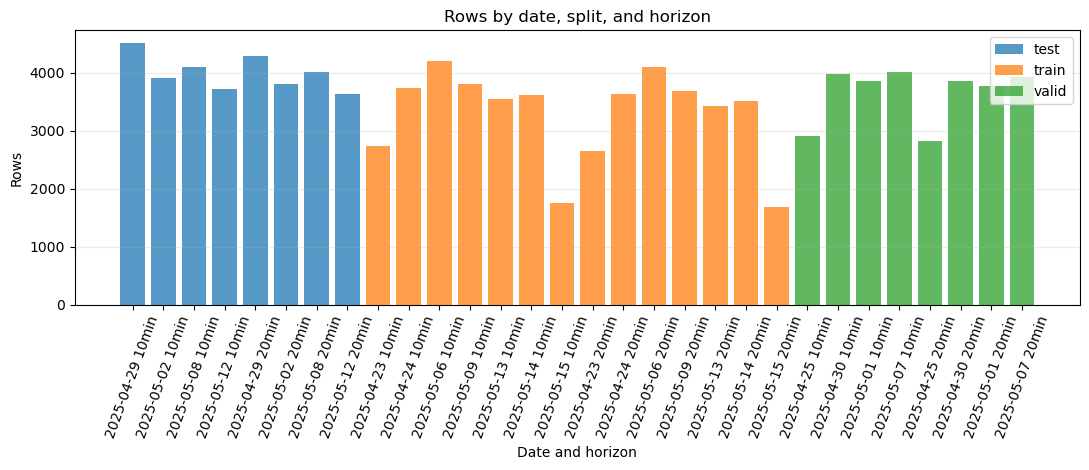

In [4]:
# row counts by target date and horizon.
date_rows = []
for target_minutes, data in datasets.items():
    for split_name in ['train', 'valid', 'test']:
        part = data[f'{split_name}_df'].copy()
        counts = part.groupby(part['timestamp_dt'].dt.date).size().reset_index(name='rows')
        counts = counts.rename(columns={'timestamp_dt': 'date'})
        counts['split'] = split_name
        counts['horizon'] = data['horizon']
        date_rows.append(counts)

date_distribution = pd.concat(date_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(11, 4.8))
for split_name, split_df in date_distribution.groupby('split'):
    ax.bar(
        split_df['date'].astype(str) + ' ' + split_df['horizon'],
        split_df['rows'],
        alpha=0.75,
        label=split_name,
    )
ax.set_title('Rows by date, split, and horizon')
ax.set_xlabel('Date and horizon')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()


## Training Functions

This section defines the baseline settings, four-parameter TPE search spaces, model wrappers, prediction table format, metric calculation, learning-curve extraction, and feature-importance extraction.

| Parameter group | Parameters | Purpose |
|---|---|---|
| LightGBM baseline | `n_estimators`, `learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree` | Fixed starting point for LightGBM comparison. |
| XGBoost baseline | `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `early_stopping_rounds` | Fixed starting point for XGBoost comparison. |
| TPE objective | validation RMSE | Selects the parameter set with the lowest validation error. |
| Prediction table | object id, timestamp, XY position, source temperature, target temperature, prediction, error | Defines the common schema used by all later plots and CSV exports. |


In [5]:
LGBM_BASELINE_PARAMS = {
    'n_estimators': N_ESTIMATORS,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
}

XGBOOST_BASELINE_PARAMS = {
    'n_estimators': N_ESTIMATORS,
    'learning_rate': 0.03,
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
}


def lgbm_search_params(trial):
    return {
        'n_estimators': N_ESTIMATORS,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 120),
        'subsample': trial.suggest_float('subsample', 0.60, 1.00),
    }


def xgboost_search_params(trial):
    return {
        'n_estimators': N_ESTIMATORS,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 12.0),
        'subsample': trial.suggest_float('subsample', 0.60, 1.00),
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    }


def train_lgbm(train_df, valid_df, feature_columns, params):
    return train_lgbm_model(
        train_df,
        valid_df,
        feature_columns,
        random_state=RANDOM_STATE,
        model_params=params,
    )


def train_xgboost(train_df, valid_df, feature_columns, params):
    models, evals_result = train_forecast_models(
        train_df,
        valid_df,
        feature_columns,
        random_state=RANDOM_STATE,
        model_params=params,
    )
    return models['mean'], evals_result


def predict_split_table(model, data, feature_columns, model_name, setting, target_minutes):
    outputs = []
    for split_name in ['train', 'valid', 'test']:
        split_df = data[f'{split_name}_df'].copy()
        prediction = model.predict(split_df[feature_columns])
        part = split_df[[
            'object_id', 'label', 'timestamp', 'timestamp_dt', 'target_timestamp',
            'display_x', 'display_y', 'source_temp', 'target_temp',
            'target_minutes_ahead', *PEOPLE_CONTEXT_FEATURES,
        ]].copy()
        part['model'] = model_name
        part['setting'] = setting
        part['target_minutes'] = float(target_minutes)
        part['horizon'] = horizon_tag(target_minutes)
        part['split'] = split_name
        part['prediction'] = prediction
        part['error'] = part['prediction'] - part['target_temp']
        outputs.append(part)
    return pd.concat(outputs, ignore_index=True)


def metric_summary(df, group_columns):
    rows = []
    for keys, group in df.groupby(group_columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        metrics = regression_metrics(group['target_temp'], group['prediction'])
        abs_error = (group['prediction'] - group['target_temp']).abs()
        rel_error = abs_error / group['target_temp'].abs().replace(0, np.nan)
        rows.append({
            **dict(zip(group_columns, keys)),
            'rows': len(group),
            'mae': metrics['mae'],
            'rmse': metrics['rmse'],
            'r2': metrics['r2'],
            'mean_error': float((group['prediction'] - group['target_temp']).mean()),
            'mape_pct': float(rel_error.mean() * 100),
            'within_10pct': float((rel_error <= 0.10).mean()),
            'within_15pct': float((rel_error <= 0.15).mean()),
        })
    return pd.DataFrame(rows)


def eval_curve_frame(evals_result, model_name, setting, target_minutes):
    rows = []
    for split_name, metrics in evals_result.items():
        rmse_values = metrics.get('rmse') or []
        for iteration, rmse in enumerate(rmse_values, start=1):
            rows.append({
                'model': model_name,
                'setting': setting,
                'target_minutes': float(target_minutes),
                'horizon': horizon_tag(target_minutes),
                'split': split_name,
                'iteration': iteration,
                'rmse': float(rmse),
            })
    return pd.DataFrame(rows)


def feature_importance_frame(model, feature_columns, model_name, setting, target_minutes):
    return pd.DataFrame({
        'model': model_name,
        'setting': setting,
        'target_minutes': float(target_minutes),
        'horizon': horizon_tag(target_minutes),
        'feature': feature_columns,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)


## Baseline Models

This section trains fixed-parameter LightGBM and XGBoost models for each forecast horizon.

The baseline results provide a reference point before hyperparameter tuning.


In [6]:
all_results = {}
prediction_parts = []
learning_curve_parts = []
importance_parts = []
metric_parts = []
parameter_rows = []

for target_minutes, data in datasets.items():
    for model_name, train_func, params in [
        ('LGBM', train_lgbm, LGBM_BASELINE_PARAMS),
        ('XGBoost', train_xgboost, XGBOOST_BASELINE_PARAMS),
    ]:
        print(f'training {model_name} baseline {target_minutes:g} min')
        model, evals_result = train_func(data['train_df'], data['valid_df'], data['feature_columns'], params)
        predictions = predict_split_table(model, data, data['feature_columns'], model_name, 'baseline', target_minutes)
        metrics = metric_summary(predictions, ['model', 'setting', 'target_minutes', 'horizon', 'split'])
        all_results[(model_name, 'baseline', target_minutes)] = {
            'model': model,
            'evals_result': evals_result,
            'predictions': predictions,
            'metrics': metrics,
            'params': params,
            'feature_columns': data['feature_columns'],
        }
        prediction_parts.append(predictions)
        metric_parts.append(metrics)
        learning_curve_parts.append(eval_curve_frame(evals_result, model_name, 'baseline', target_minutes))
        importance_parts.append(feature_importance_frame(model, data['feature_columns'], model_name, 'baseline', target_minutes))
        parameter_rows.append({'model': model_name, 'setting': 'baseline', 'target_minutes': target_minutes, 'horizon': horizon_tag(target_minutes), **params})

baseline_metrics = pd.concat(metric_parts, ignore_index=True).query("setting == 'baseline'")
display(baseline_metrics)


training LGBM baseline 10 min
training XGBoost baseline 10 min
training LGBM baseline 20 min
training XGBoost baseline 20 min


,model,setting,target_minutes,horizon,split,rows,mae,rmse,r2,mean_error,mape_pct,within_10pct,within_15pct
0,LGBM,baseline,10.0,10min,test,16246,0.481596,0.696363,0.881451,-0.029524,1.955305,0.990952,0.998338
1,LGBM,baseline,10.0,10min,train,23408,0.410879,0.616121,0.916208,-0.000012,1.690527,0.993720,0.999017
2,LGBM,baseline,10.0,10min,valid,14771,0.519054,0.733622,0.821192,0.094683,2.212519,0.990048,0.998375
3,XGBoost,baseline,10.0,10min,test,16246,0.480374,0.693782,0.882328,-0.038655,1.948770,0.991259,0.998523
4,XGBoost,baseline,10.0,10min,train,23408,0.404379,0.597831,0.921109,-0.000598,1.664390,0.994788,0.999316
5,XGBoost,baseline,10.0,10min,valid,14771,0.524225,0.738722,0.818697,0.103753,2.235660,0.990657,0.998307
6,LGBM,baseline,20.0,20min,test,15751,0.572097,0.803975,0.834042,-0.042108,2.321005,0.988572,0.997524
7,LGBM,baseline,20.0,20min,train,22705,0.497812,0.713700,0.884694,-0.000015,2.049869,0.990751,0.998503
8,LGBM,baseline,20.0,20min,valid,14377,0.633037,0.876353,0.735561,0.146810,2.699496,0.981776,0.996244
9,XGBoost,baseline,20.0,20min,test,15751,0.570832,0.803968,0.834045,-0.047327,2.314038,0.988636,0.997460


## TPE Parameter Search

This section runs Optuna TPE search independently for each model and forecast horizon.

TPE changes the model hyperparameter values inside the listed search ranges. It does not change the input feature values in the dataset.

| Model | Tuned parameter | Search range | Purpose |
|---|---|---:|---|
| LightGBM | `learning_rate` | 0.005 to 0.08 | Controls the contribution of each boosting iteration. |
| LightGBM | `num_leaves` | 15 to 127 | Controls leaf-wise tree complexity. |
| LightGBM | `min_child_samples` | 10 to 120 | Sets the minimum rows required in a leaf. |
| LightGBM | `subsample` | 0.60 to 1.00 | Samples rows per tree to reduce overfitting. |
| XGBoost | `learning_rate` | 0.005 to 0.08 | Controls the contribution of each boosting iteration. |
| XGBoost | `max_depth` | 3 to 10 | Controls level-wise tree depth. |
| XGBoost | `min_child_weight` | 1.0 to 12.0 | Requires enough sample weight before splitting. |
| XGBoost | `subsample` | 0.60 to 1.00 | Samples rows per tree to reduce overfitting. |


In [7]:
try:
    import optuna
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Missing optuna. Install optuna in the active environment before running this cell.') from exc


def tune_model(model_name, target_minutes, data):
    train_func = train_lgbm if model_name == 'LGBM' else train_xgboost
    search_func = lgbm_search_params if model_name == 'LGBM' else xgboost_search_params

    def objective(trial):
        params = search_func(trial)
        model, _ = train_func(data['train_df'], data['valid_df'], data['feature_columns'], params)
        valid_prediction = model.predict(data['valid_df'][data['feature_columns']])
        return regression_metrics(data['valid_df']['target_temp'], valid_prediction)['rmse']

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_PER_HORIZON, show_progress_bar=True)
    return study


studies = {}
best_params_by_model = {}
for target_minutes, data in datasets.items():
    for model_name in MODEL_ORDER:
        print(f'tuning {model_name} {target_minutes:g} min')
        study = tune_model(model_name, target_minutes, data)
        studies[(model_name, target_minutes)] = study
        best_params_by_model[(model_name, target_minutes)] = study.best_params

best_params_rows = []
for (model_name, target_minutes), study in studies.items():
    row = {
        'model': model_name,
        'target_minutes': float(target_minutes),
        'horizon': horizon_tag(target_minutes),
        'best_valid_rmse': study.best_value,
    }
    row.update(study.best_params)
    best_params_rows.append(row)

best_params_table = pd.DataFrame(best_params_rows).sort_values(['model', 'target_minutes'])
best_params_json = TABLE_OUTPUT_DIR / 'v2_06_best_tpe_params.json'
best_params_json.write_text(json.dumps(best_params_rows, indent=2), encoding='utf-8')
display(best_params_table)
print('saved:', best_params_json)


/opt/miniconda3/envs/itp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-01 21:57:05,479] A new study created in memory with name: no-name-48884bad-39ec-4eea-9227-e7a1afd900d4


tuning LGBM 10 min


Best trial: 0. Best value: 0.733045:   2%|▏         | 1/50 [00:01<01:31,  1.86s/it]

[I 2026-06-01 21:57:07,358] Trial 0 finished with value: 0.7330447716991165 and parameters: {'learning_rate': 0.03448279561431617, 'num_leaves': 47, 'min_child_samples': 35, 'subsample': 0.8205259076331565}. Best is trial 0 with value: 0.7330447716991165.


Best trial: 0. Best value: 0.733045:   4%|▍         | 2/50 [00:03<01:30,  1.88s/it]

...

[I 2026-06-01 22:03:25,019] Trial 48 finished with value: 0.8734556625282579 and parameters: {'learning_rate': 0.056142193186044874, 'max_depth': 5, 'min_child_weight': 5.8178726429648835, 'subsample': 0.7845483650868247}. Best is trial 43 with value: 0.860606271668798.


Best trial: 43. Best value: 0.860606: 100%|██████████| 50/50 [01:11<00:00,  1.43s/it]

[I 2026-06-01 22:03:25,932] Trial 49 finished with value: 0.8659796389020912 and parameters: {'learning_rate': 0.03311262243924446, 'max_depth': 4, 'min_child_weight': 10.890129985257758, 'subsample': 0.8632523494797423}. Best is trial 43 with value: 0.860606271668798.


,model,target_minutes,horizon,best_valid_rmse,learning_rate,num_leaves,min_child_samples,subsample,max_depth,min_child_weight
0,LGBM,10.0,10min,0.729665,0.077405,15.0,79.0,0.986121,NaN,NaN
2,LGBM,20.0,20min,0.863808,0.077016,15.0,83.0,0.985291,NaN,NaN
1,XGBoost,10.0,10min,0.727291,0.028065,NaN,NaN,0.639320,3.0,6.094253
3,XGBoost,20.0,20min,0.860606,0.055057,NaN,NaN,0.689971,4.0,9.909818


saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/tables/v2_06_best_tpe_params.json


## TPE Parameters

This section displays the best TPE parameters and the validation RMSE observed during each TPE trial.

The trial plot uses four colors for the four trained model-horizon settings: LGBM 10 min, LGBM 20 min, XGBoost 10 min, and XGBoost 20 min.


,model,target_minutes,horizon,best_valid_rmse,learning_rate,num_leaves,min_child_samples,subsample,max_depth,min_child_weight
0,LGBM,10.0,10min,0.729665,0.077405,15.0,79.0,0.986121,NaN,NaN
2,LGBM,20.0,20min,0.863808,0.077016,15.0,83.0,0.985291,NaN,NaN
1,XGBoost,10.0,10min,0.727291,0.028065,NaN,NaN,0.639320,3.0,6.094253
3,XGBoost,20.0,20min,0.860606,0.055057,NaN,NaN,0.689971,4.0,9.909818


,model,target_minutes,horizon,trial,valid_rmse,learning_rate,num_leaves,min_child_samples,subsample,max_depth,min_child_weight
0,LGBM,10.0,10min,0,0.733045,0.034483,47.0,35.0,0.820526,NaN,NaN
1,LGBM,10.0,10min,1,0.736721,0.036753,62.0,118.0,0.873932,NaN,NaN
2,LGBM,10.0,10min,2,0.737691,0.018970,59.0,48.0,0.891620,NaN,NaN
3,LGBM,10.0,10min,3,0.731259,0.016868,21.0,54.0,0.895198,NaN,NaN
4,LGBM,10.0,10min,4,0.732550,0.008293,34.0,69.0,0.812731,NaN,NaN


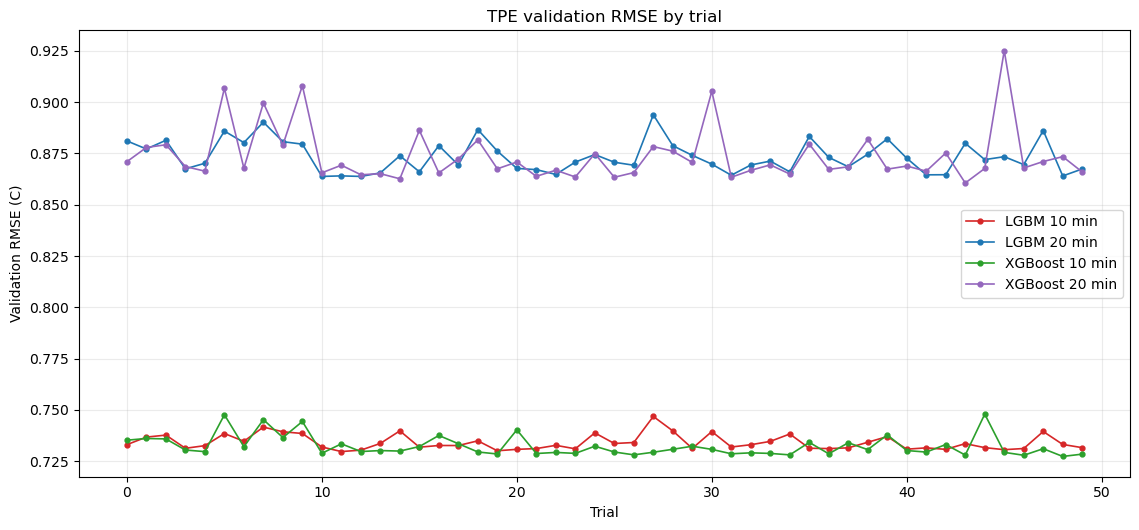

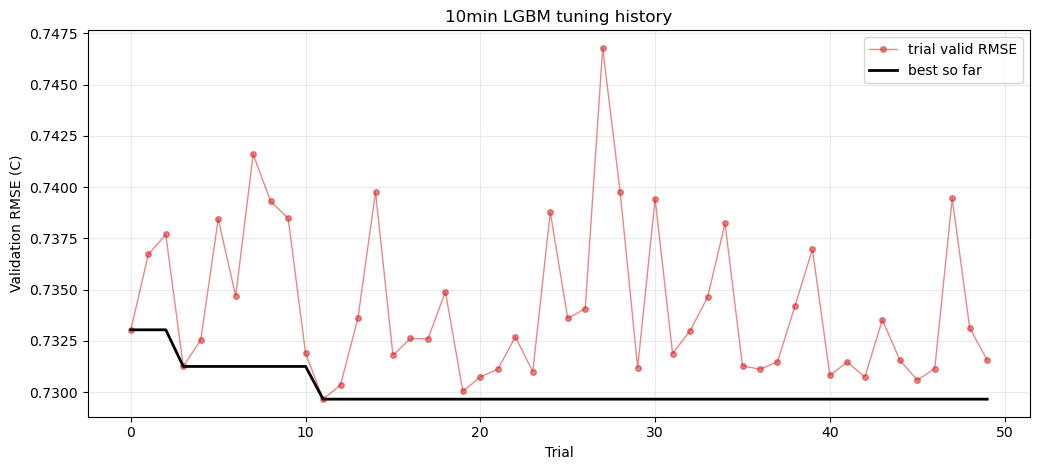

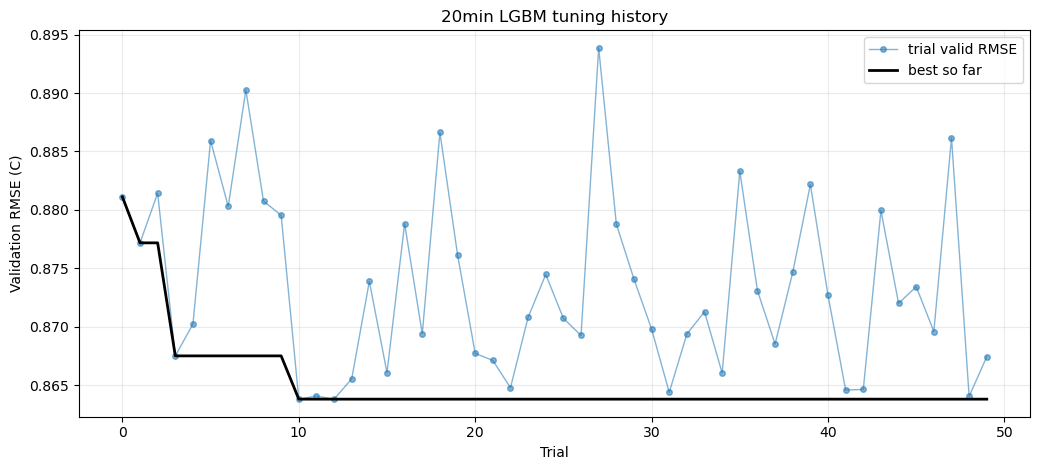

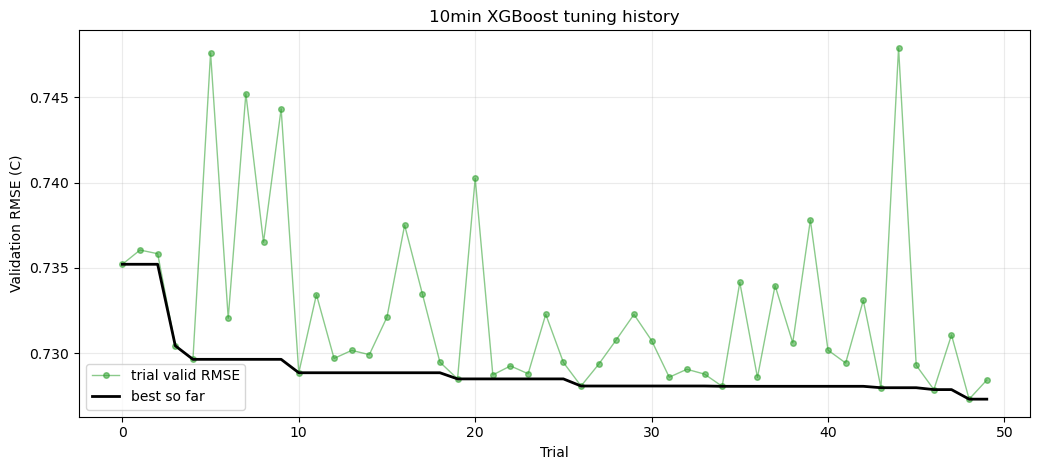

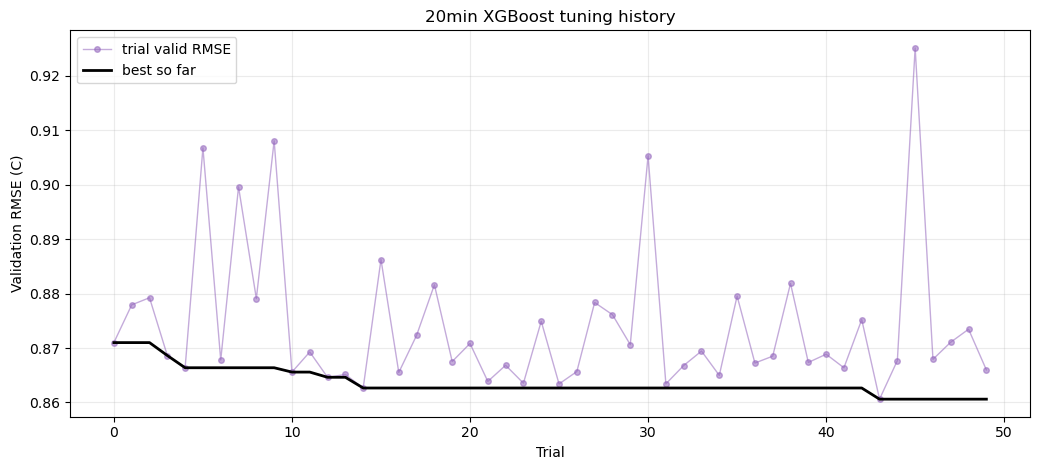

In [10]:
display(best_params_table)

tpe_trial_rows = []
for (model_name, target_minutes), study in studies.items():
    for trial in study.trials:
        if trial.value is None:
            continue
        row = {
            'model': model_name,
            'target_minutes': float(target_minutes),
            'horizon': horizon_tag(target_minutes),
            'trial': trial.number,
            'valid_rmse': float(trial.value),
        }
        for param_name, param_value in trial.params.items():
            row[param_name] = param_value
        tpe_trial_rows.append(row)

tpe_trials = pd.DataFrame(tpe_trial_rows)
display(tpe_trials.sort_values(['model', 'target_minutes', 'trial']).head())

fig, ax = plt.subplots(figsize=(11.5, 5.4))
for (model_name, target_minutes), part in tpe_trials.groupby(['model', 'target_minutes']):
    part = part.sort_values('trial')
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    ax.plot(
        part['trial'],
        part['valid_rmse'],
        marker='o',
        markersize=3.5,
        linewidth=1.2,
        color=color,
        label=f'{model_name} {target_minutes:g} min',
    )
ax.set_title('TPE validation RMSE by trial')
ax.set_xlabel('Trial')
ax.set_ylabel('Validation RMSE (C)')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()


for (model_name, target_minutes), part in tpe_trials.groupby(['model', 'target_minutes']):
    part = part.sort_values('trial').copy()
    part['best_so_far'] = part['valid_rmse'].cummin()
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.plot(
        part['trial'],
        part['valid_rmse'],
        marker='o',
        markersize=4,
        linewidth=1.0,
        color=color,
        alpha=0.55,
        label='trial valid RMSE',
    )
    ax.plot(
        part['trial'],
        part['best_so_far'],
        color='black',
        linewidth=2.0,
        label='best so far',
    )
    ax.set_title(f'{target_minutes:g}min {model_name} tuning history')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Validation RMSE (C)')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    fig.tight_layout()


## Tuned Models

This section retrains LightGBM and XGBoost using the best TPE parameters for each horizon.

The trained tuned models generate the final prediction tables, metrics, learning curves, and feature-importance results used in the remaining sections.


In [11]:
for target_minutes, data in datasets.items():
    for model_name, train_func, baseline_params in [
        ('LGBM', train_lgbm, LGBM_BASELINE_PARAMS),
        ('XGBoost', train_xgboost, XGBOOST_BASELINE_PARAMS),
    ]:
        tuned_params = baseline_params.copy()
        tuned_params.update(best_params_by_model[(model_name, target_minutes)])
        if model_name == 'XGBoost':
            tuned_params['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
        print(f'training {model_name} tuned {target_minutes:g} min')
        model, evals_result = train_func(data['train_df'], data['valid_df'], data['feature_columns'], tuned_params)
        predictions = predict_split_table(model, data, data['feature_columns'], model_name, 'tuned', target_minutes)
        metrics = metric_summary(predictions, ['model', 'setting', 'target_minutes', 'horizon', 'split'])
        all_results[(model_name, 'tuned', target_minutes)] = {
            'model': model,
            'evals_result': evals_result,
            'predictions': predictions,
            'metrics': metrics,
            'params': tuned_params,
            'feature_columns': data['feature_columns'],
        }
        prediction_parts.append(predictions)
        metric_parts.append(metrics)
        learning_curve_parts.append(eval_curve_frame(evals_result, model_name, 'tuned', target_minutes))
        importance_parts.append(feature_importance_frame(model, data['feature_columns'], model_name, 'tuned', target_minutes))
        parameter_rows.append({'model': model_name, 'setting': 'tuned', 'target_minutes': target_minutes, 'horizon': horizon_tag(target_minutes), **tuned_params})

all_predictions = pd.concat(prediction_parts, ignore_index=True)
all_metrics = pd.concat(metric_parts, ignore_index=True)
learning_curves = pd.concat(learning_curve_parts, ignore_index=True)
feature_importance = pd.concat(importance_parts, ignore_index=True)
final_parameter_table = pd.DataFrame(parameter_rows).sort_values(['model', 'target_minutes', 'setting'])

display(all_metrics.sort_values(['model', 'target_minutes', 'setting', 'split']))
display(final_parameter_table)


training LGBM tuned 10 min
training XGBoost tuned 10 min
training LGBM tuned 20 min
training XGBoost tuned 20 min


,model,setting,target_minutes,horizon,split,rows,mae,rmse,r2,mean_error,mape_pct,within_10pct,within_15pct
0,LGBM,baseline,10.0,10min,test,16246,0.481596,0.696363,0.881451,-0.029524,1.955305,0.990952,0.998338
1,LGBM,baseline,10.0,10min,train,23408,0.410879,0.616121,0.916208,-0.000012,1.690527,0.993720,0.999017
2,LGBM,baseline,10.0,10min,valid,14771,0.519054,0.733622,0.821192,0.094683,2.212519,0.990048,0.998375
12,LGBM,tuned,10.0,10min,test,16246,0.476359,0.693937,0.882276,-0.030763,1.933723,0.990890,0.998092
13,LGBM,tuned,10.0,10min,train,23408,0.437615,0.680775,0.897700,-0.000030,1.797113,0.989918,0.997821
14,LGBM,tuned,10.0,10min,valid,14771,0.514705,0.729665,0.823116,0.097222,2.195177,0.991064,0.998172
6,LGBM,baseline,20.0,20min,test,15751,0.572097,0.803975,0.834042,-0.042108,2.321005,0.988572,0.997524
7,LGBM,baseline,20.0,20min,train,22705,0.497812,0.713700,0.884694,-0.000015,2.049869,0.990751,0.998503
8,LGBM,baseline,20.0,20min,valid,14377,0.633037,0.876353,0.735561,0.146810,2.699496,0.981776,0.996244
18,LGBM,tuned,20.0,20min,test,15751,0.567222,0.800351,0.835535,-0.042431,2.300340,0.988763,0.997270


,model,setting,target_minutes,horizon,n_estimators,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,max_depth,min_child_weight,early_stopping_rounds
0,LGBM,baseline,10.0,10min,2000,0.030000,31.0,20.0,0.850000,0.85,NaN,NaN,NaN
4,LGBM,tuned,10.0,10min,2000,0.077405,15.0,79.0,0.986121,0.85,NaN,NaN,NaN
2,LGBM,baseline,20.0,20min,2000,0.030000,31.0,20.0,0.850000,0.85,NaN,NaN,NaN
6,LGBM,tuned,20.0,20min,2000,0.077016,15.0,83.0,0.985291,0.85,NaN,NaN,NaN
1,XGBoost,baseline,10.0,10min,2000,0.030000,NaN,NaN,0.850000,0.85,6.0,3.000000,100.0
5,XGBoost,tuned,10.0,10min,2000,0.028065,NaN,NaN,0.639320,0.85,3.0,6.094253,100.0
3,XGBoost,baseline,20.0,20min,2000,0.030000,NaN,NaN,0.850000,0.85,6.0,3.000000,100.0
7,XGBoost,tuned,20.0,20min,2000,0.055057,NaN,NaN,0.689971,0.85,4.0,9.909818,100.0


## Prediction Outputs

This section exports one complete test-set prediction CSV aligned by source object row, plus separate 10 min and 20 min CSV files.

Each row starts from the available source data and reports the future target temperature and tuned model predictions for the requested horizon.

| Output file | Content |
|---|---|
| `v2_06_prediction_results.csv` | One source row with 10 min and 20 min tuned predictions from LGBM and XGBoost. |
| `v2_06_prediction_results_10min.csv` | One source row with only 10 min target temperature and tuned predictions. |
| `v2_06_prediction_results_20min.csv` | One source row with only 20 min target temperature and tuned predictions. |
| `v2_06_model_metrics.csv` | Metrics for train, validation, and test splits. |
| `v2_06_final_parameter_table.csv` | Baseline and tuned parameter settings. |


In [12]:
# export one source-row prediction table for external use.
tuned_test_predictions = all_predictions.query("setting == 'tuned' and split == 'test'").copy()
tuned_test_predictions['timestamp_dt'] = pd.to_datetime(tuned_test_predictions['timestamp_dt'])
tuned_test_predictions['target_timestamp'] = pd.to_datetime(tuned_test_predictions['target_timestamp'])
tuned_test_predictions['source_timestamp'] = tuned_test_predictions['timestamp_dt']
tuned_test_predictions['source_date'] = tuned_test_predictions['source_timestamp'].dt.date.astype(str)

source_columns = [
    'object_id',
    'label',
    'source_timestamp',
    'source_date',
    'source_temp',
    'display_x',
    'display_y',
]


def build_prediction_export_for_horizon(predictions, target_minutes):
    horizon_df = predictions[predictions['target_minutes'] == float(target_minutes)].copy()
    tag = horizon_tag(target_minutes)
    output = horizon_df[source_columns].drop_duplicates().sort_values(source_columns).reset_index(drop=True)

    target_info = (
        horizon_df
        .groupby(source_columns, as_index=False)
        .agg(
            **{
                f'{tag}_target_timestamp': ('target_timestamp', 'first'),
                f'{tag}_target_temp': ('target_temp', 'median'),
                f'{tag}_actual_minutes_ahead': ('target_minutes_ahead', 'median'),
            }
        )
    )
    output = output.merge(target_info, on=source_columns, how='left')

    for model_name in MODEL_ORDER:
        model_df = horizon_df[horizon_df['model'] == model_name].copy()
        if model_df.empty:
            continue
        model_prefix = model_name.lower().replace('xgboost', 'xgboost')
        model_predictions = (
            model_df
            .groupby(source_columns, as_index=False)
            .agg(**{f'{model_prefix}_{tag}_prediction': ('prediction', 'median')})
        )
        output = output.merge(model_predictions, on=source_columns, how='left')

    return output


horizon_exports = {
    float(target_minutes): build_prediction_export_for_horizon(tuned_test_predictions, target_minutes)
    for target_minutes in TARGET_MINUTES_LIST
}

complete_prediction_results = None
for target_minutes in TARGET_MINUTES_LIST:
    horizon_df = horizon_exports[float(target_minutes)]
    if complete_prediction_results is None:
        complete_prediction_results = horizon_df.copy()
    else:
        horizon_specific_columns = [column for column in horizon_df.columns if column not in source_columns]
        complete_prediction_results = complete_prediction_results.merge(
            horizon_df[source_columns + horizon_specific_columns],
            on=source_columns,
            how='outer',
        )

complete_output_csv = PREDICTION_OUTPUT_DIR / 'v2_06_prediction_results.csv'
complete_prediction_results.to_csv(complete_output_csv, index=False)
print('saved:', complete_output_csv, 'rows:', len(complete_prediction_results))

for target_minutes, horizon_df in horizon_exports.items():
    output_csv = PREDICTION_OUTPUT_DIR / f'v2_06_prediction_results_{horizon_tag(target_minutes)}.csv'
    horizon_df.to_csv(output_csv, index=False)
    print('saved:', output_csv, 'rows:', len(horizon_df))

# remove output files from earlier versions of this notebook to avoid using stale schemas.
for old_name in [
    'v2_06_tuned_test_predictions_10min.csv',
    'v2_06_tuned_test_predictions_20min.csv',
    'v2_06_tuned_test_predictions_wide.csv',
]:
    old_path = PREDICTION_OUTPUT_DIR / old_name
    if old_path.exists():
        old_path.unlink()
        print('removed old output:', old_path)

metrics_csv = TABLE_OUTPUT_DIR / 'v2_06_model_metrics.csv'
params_csv = TABLE_OUTPUT_DIR / 'v2_06_final_parameter_table.csv'
all_metrics.to_csv(metrics_csv, index=False)
final_parameter_table.to_csv(params_csv, index=False)
print('saved:', metrics_csv)
print('saved:', params_csv)

print('complete output columns:')
display(pd.DataFrame({'column': complete_prediction_results.columns}))


saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/predictions/v2_06_prediction_results.csv rows: 16487
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/predictions/v2_06_prediction_results_10min.csv rows: 16246
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/predictions/v2_06_prediction_results_20min.csv rows: 15751
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/tables/v2_06_model_metrics.csv
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/tables/v2_06_final_parameter_table.csv
complete output columns:


,column
0,object_id
1,label
2,source_timestamp
3,source_date
4,source_temp
5,display_x
6,display_y
7,10min_target_timestamp
8,10min_target_temp
9,10min_actual_minutes_ahead


## Train and Validation Loss

This section plots boosting RMSE over training iterations for tuned models.

The curves are used to check whether validation loss stops improving and whether training loss continues decreasing while validation loss plateaus or rises.


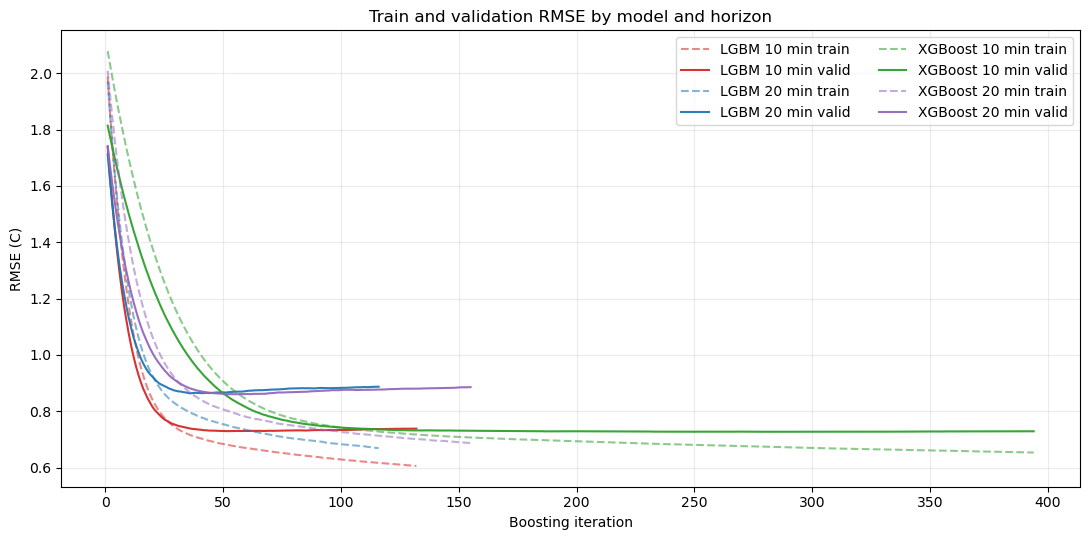

In [13]:
plot_curves = learning_curves[learning_curves['setting'] == 'tuned'].copy()
fig, ax = plt.subplots(figsize=(11, 5.5))
for (model_name, target_minutes, split_name), part in plot_curves.groupby(['model', 'target_minutes', 'split']):
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    linestyle = '-' if split_name == 'valid' else '--'
    alpha = 0.95 if split_name == 'valid' else 0.55
    ax.plot(
        part['iteration'],
        part['rmse'],
        color=color,
        linestyle=linestyle,
        alpha=alpha,
        label=f'{model_name} {target_minutes:g} min {split_name}',
    )
ax.set_title('Train and validation RMSE by model and horizon')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('RMSE (C)')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()


## RMSE Comparison

This section compares tuned test RMSE across model type and forecast horizon.

| Dimension | Values |
|---|---|
| Model | LightGBM, XGBoost |
| Setting | tuned only |
| Horizon | 10 min, 20 min |


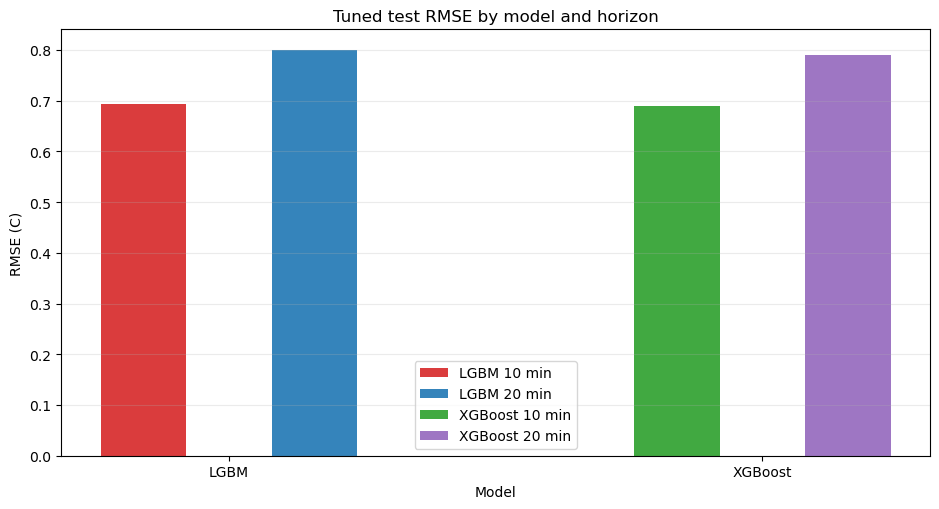

In [14]:
test_metrics_all = all_metrics[all_metrics['split'] == 'test'].copy()
test_metrics = test_metrics_all[test_metrics_all['setting'] == 'tuned'].copy()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
base_positions = np.arange(len(MODEL_ORDER))
bar_width = 0.32
horizon_offsets = np.linspace(-bar_width / 2, bar_width / 2, len(TARGET_MINUTES_LIST))

for model_index, model_name in enumerate(MODEL_ORDER):
    for offset, target_minutes in zip(horizon_offsets, TARGET_MINUTES_LIST):
        part = test_metrics[
            (test_metrics['model'] == model_name)
            & (test_metrics['target_minutes'] == float(target_minutes))
        ]
        if part.empty:
            continue
        value = part['rmse'].iloc[0]
        color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
        ax.bar(
            model_index + offset,
            value,
            width=bar_width / max(len(TARGET_MINUTES_LIST), 1),
            color=color,
            alpha=0.9,
            label=f'{model_name} {target_minutes:g} min',
        )

ax.set_xticks(base_positions)
ax.set_xticklabels(MODEL_ORDER)
ax.set_title('Tuned test RMSE by model and horizon')
ax.set_xlabel('Model')
ax.set_ylabel('RMSE (C)')
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()


## Feature Importance

This section shows the most influential model features for the tuned models.

The table keeps all feature-importance values, while the plot displays the top features for readability.


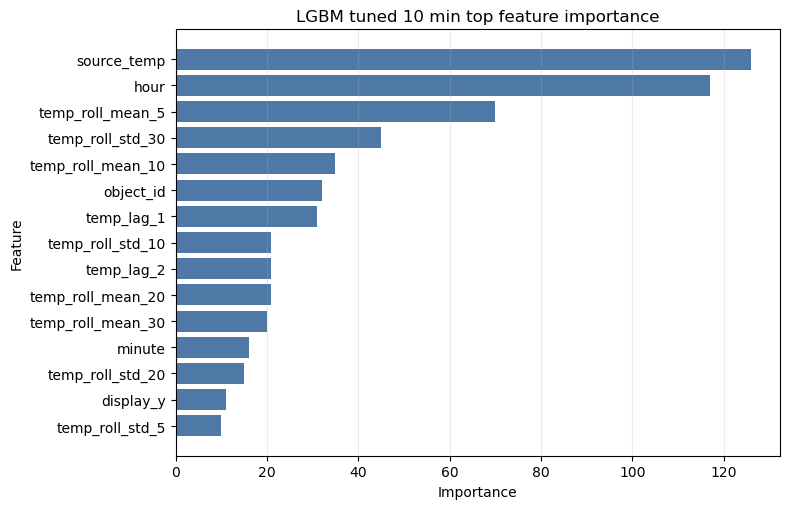

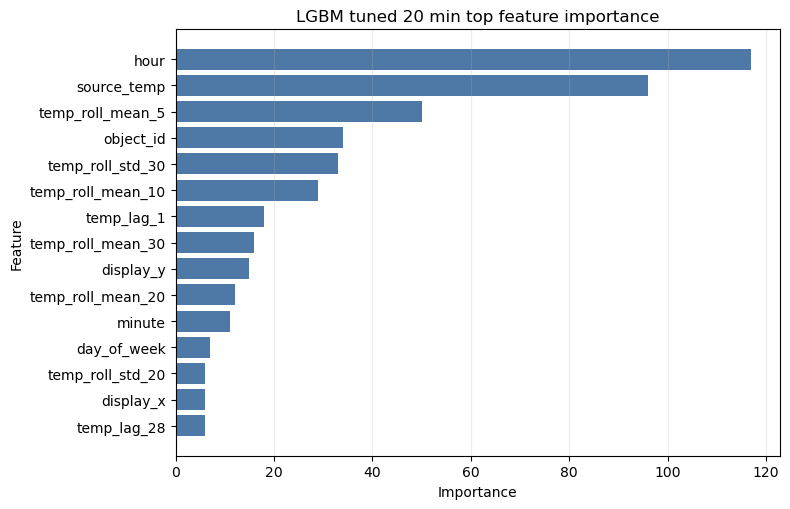

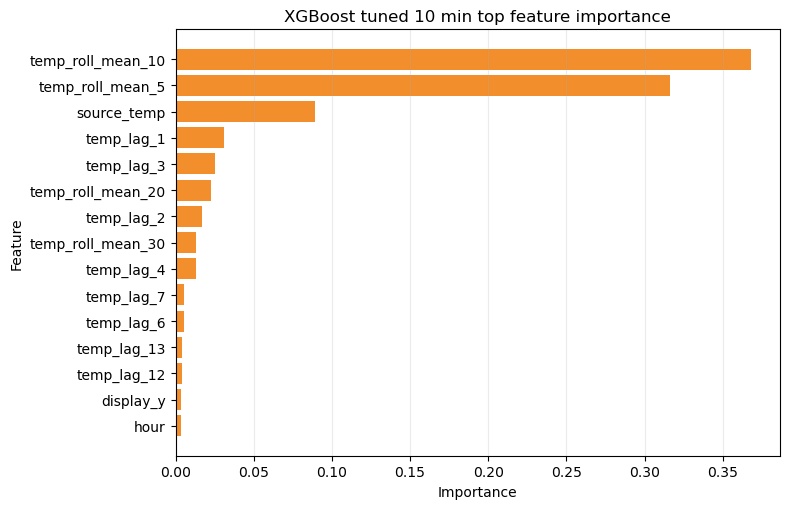

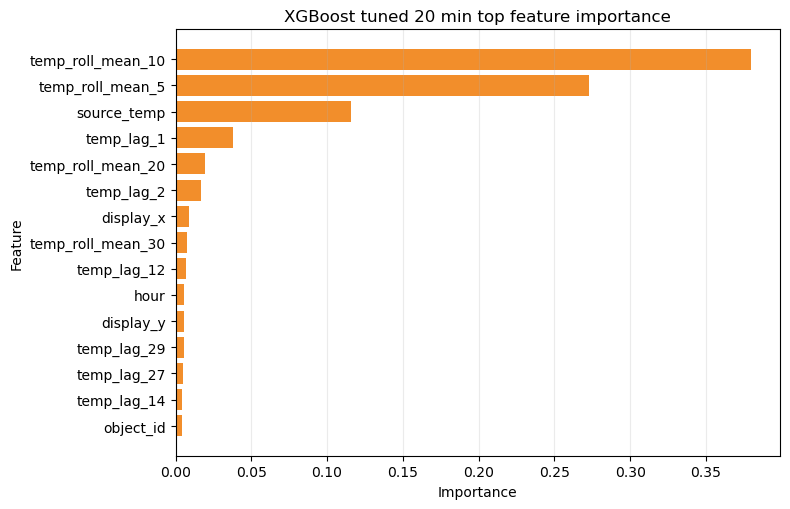

In [15]:
TOP_FEATURES = 15
importance_plot = feature_importance[feature_importance['setting'] == 'tuned'].copy()
for (model_name, target_minutes), part in importance_plot.groupby(['model', 'target_minutes']):
    top = part.sort_values('importance', ascending=False).head(TOP_FEATURES).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    ax.barh(top['feature'], top['importance'], color=MODEL_COLORS.get(model_name, '#777777'))
    ax.set_title(f'{model_name} tuned {target_minutes:g} min top feature importance')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()


## Prediction Scatter

This section plots predicted temperature against ground truth temperature for tuned models.

Each model-horizon setting is shown as a separate parity plot: LGBM 10 min, LGBM 20 min, XGBoost 10 min, and XGBoost 20 min. The diagonal line represents perfect prediction. The colored relative-error bounds show ±10% and ±15% ranges from the ground truth value.


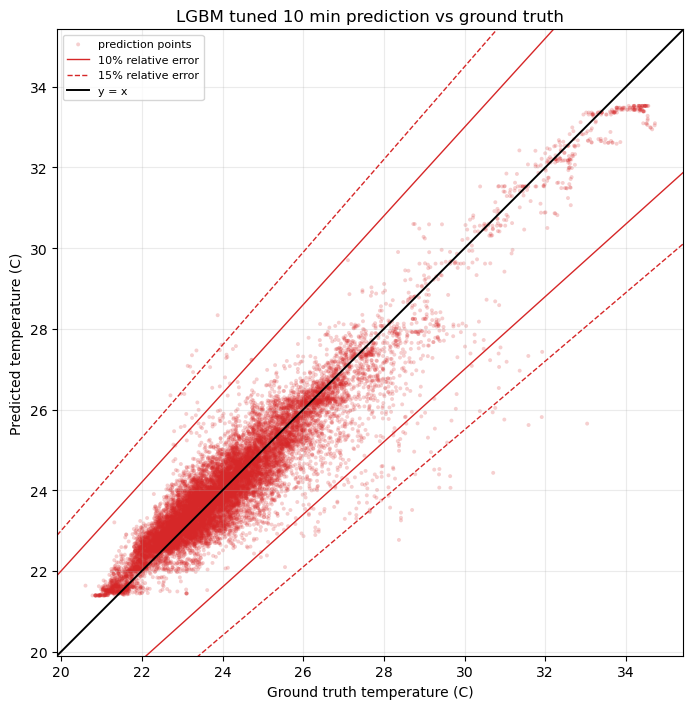

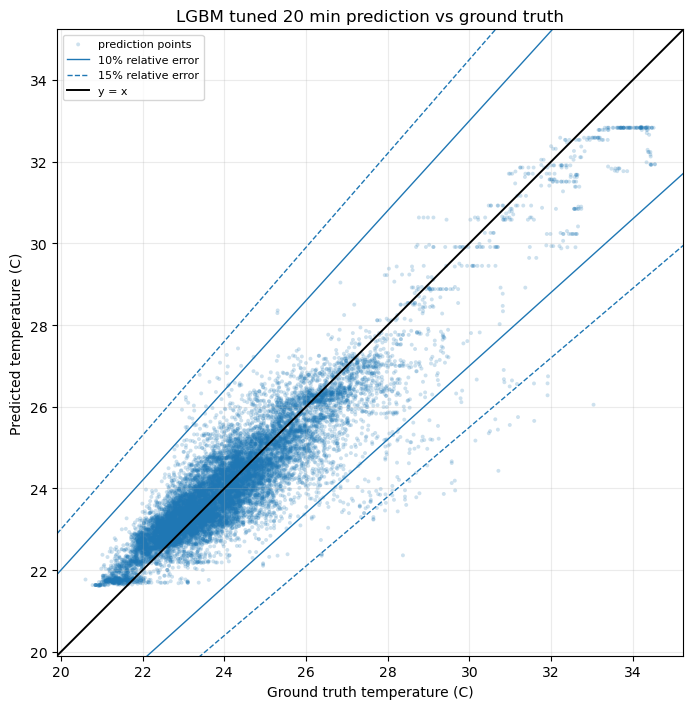

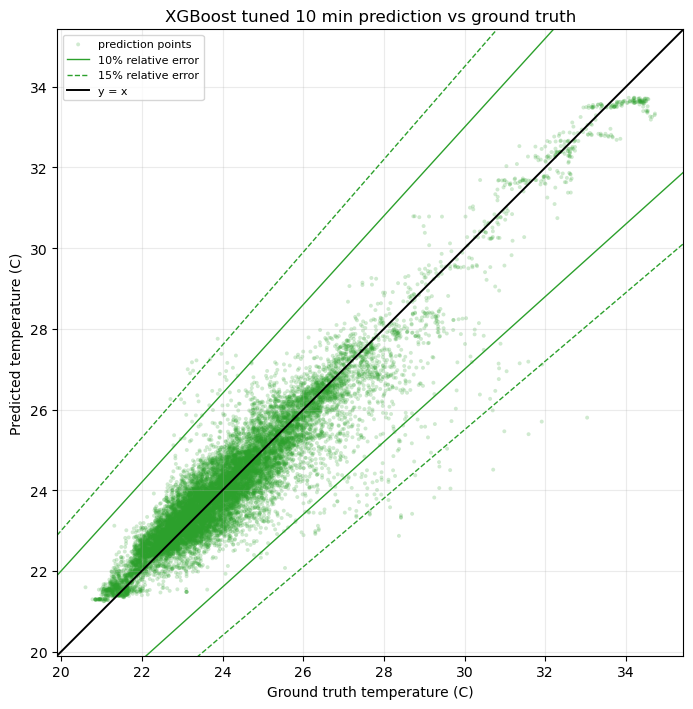

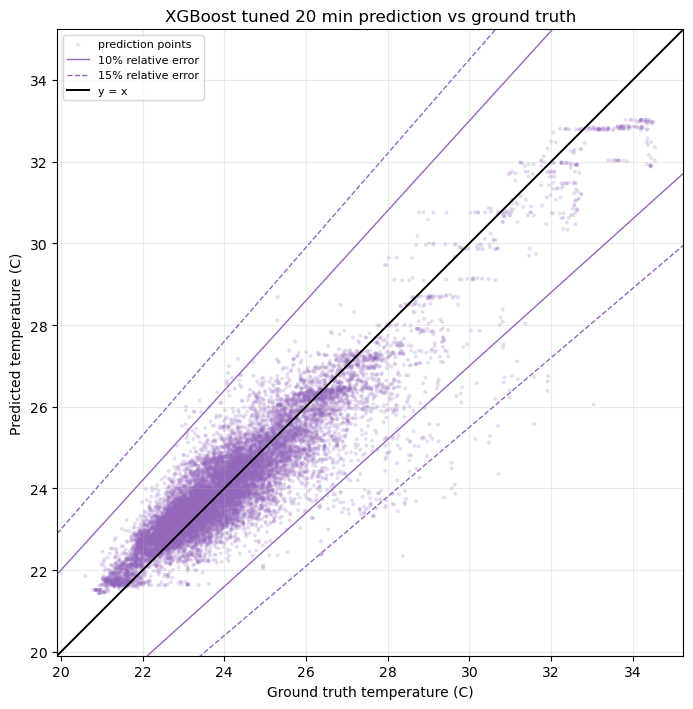

In [16]:
def add_relative_error_bounds(ax, line_x, model_name, target_minutes):
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    ax.plot(line_x, line_x * 1.10, color=color, linestyle='-', linewidth=1.0, label='10% relative error')
    ax.plot(line_x, line_x * 0.90, color=color, linestyle='-', linewidth=1.0)
    ax.plot(line_x, line_x * 1.15, color=color, linestyle='--', linewidth=1.0, label='15% relative error')
    ax.plot(line_x, line_x * 0.85, color=color, linestyle='--', linewidth=1.0)


scatter_df = tuned_test_predictions.dropna(subset=['target_temp', 'prediction']).copy()
for model_name in MODEL_ORDER:
    for target_minutes in TARGET_MINUTES_LIST:
        part = scatter_df[
            (scatter_df['model'] == model_name)
            & (scatter_df['target_minutes'] == float(target_minutes))
        ].copy()
        if part.empty:
            continue

        xy_min = min(part['target_temp'].min(), part['prediction'].min())
        xy_max = max(part['target_temp'].max(), part['prediction'].max())
        pad = max((xy_max - xy_min) * 0.05, 0.2)
        plot_min = max(xy_min - pad, 0.01)
        plot_max = xy_max + pad
        line_x = np.linspace(plot_min, plot_max, 200)
        color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')

        fig, ax = plt.subplots(figsize=(7.2, 7.2))
        ax.scatter(
            part['target_temp'],
            part['prediction'],
            s=8,
            alpha=0.22,
            color=color,
            edgecolors='none',
            label='prediction points',
        )
        add_relative_error_bounds(ax, line_x, model_name, float(target_minutes))
        ax.plot(line_x, line_x, color='black', linewidth=1.4, label='y = x')
        ax.set_xlim(plot_min, plot_max)
        ax.set_ylim(plot_min, plot_max)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'{model_name} tuned {target_minutes:g} min prediction vs ground truth')
        ax.set_xlabel('Ground truth temperature (C)')
        ax.set_ylabel('Predicted temperature (C)')
        ax.grid(alpha=0.25)
        ax.legend(loc='best', fontsize=8)
        fig.tight_layout()


## Error Distribution

This section plots the distribution of prediction error for tuned models.

The error is defined as `prediction - target_temp`, so positive values indicate overprediction and negative values indicate underprediction. The x-axis is fixed at -3 to 3 C for visual comparison. Each mean error is listed in the legend.


,model,target_minutes,horizon,label,rows,mae,rmse,r2,mean_error,mape_pct,within_10pct,within_15pct
2,LGBM,10.0,10min,Screen,1937,0.604695,0.817065,0.819240,-0.022764,2.400162,0.992256,1.000000
1,LGBM,10.0,10min,Machine,6469,0.499357,0.791295,0.754846,-0.003500,2.057562,0.980368,0.995362
3,LGBM,10.0,10min,Window,1887,0.513611,0.687564,0.952880,-0.139511,1.908380,0.997350,0.999470
0,LGBM,10.0,10min,Light,5953,0.397802,0.516399,0.810109,-0.028520,1.655411,0.999832,1.000000
6,LGBM,20.0,20min,Screen,1862,0.764909,1.016209,0.705062,-0.022302,3.047598,0.984425,0.998389
5,LGBM,20.0,20min,Machine,6267,0.584934,0.879422,0.692991,0.024173,2.420477,0.977342,0.993936
7,LGBM,20.0,20min,Window,1839,0.659146,0.866432,0.920079,-0.282884,2.415441,0.997825,0.998912
4,LGBM,20.0,20min,Light,5783,0.455146,0.579090,0.749993,-0.044627,1.892945,0.999654,1.000000
10,XGBoost,10.0,10min,Screen,1937,0.595286,0.803633,0.825135,-0.003129,2.364491,0.994837,1.000000
9,XGBoost,10.0,10min,Machine,6469,0.497602,0.792397,0.754163,-0.016470,2.046855,0.979904,0.995053


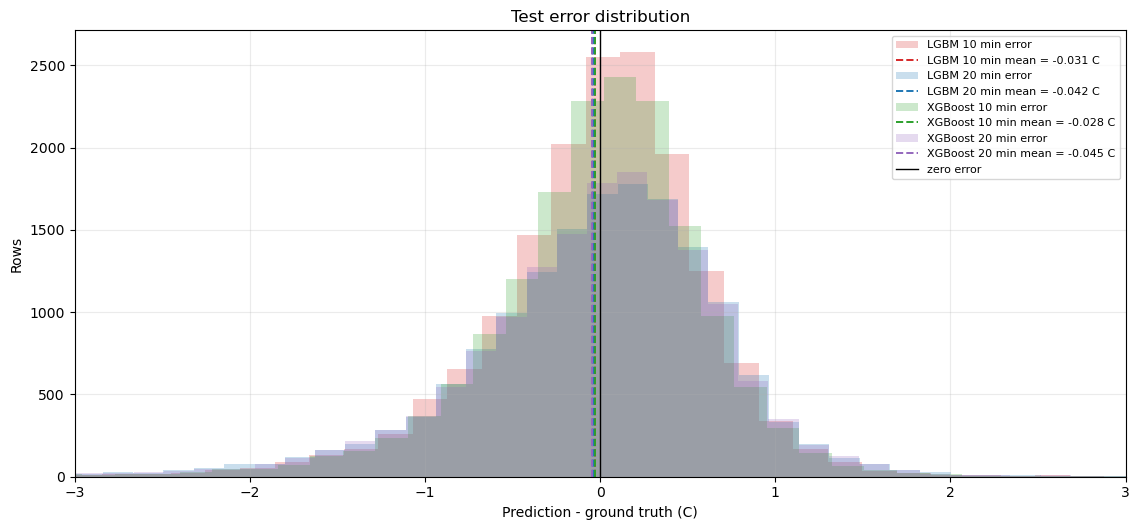

In [17]:
fig, ax = plt.subplots(figsize=(11.5, 5.4))
for (model_name, target_minutes), part in tuned_test_predictions.groupby(['model', 'target_minutes']):
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    label = f'{model_name} {target_minutes:g} min'
    mean_error = part['error'].mean()
    ax.hist(part['error'], bins=60, alpha=0.24, color=color, label=f'{label} error')
    ax.axvline(mean_error, color=color, linestyle='--', linewidth=1.4, label=f'{label} mean = {mean_error:.3f} C')
ax.axvline(0, color='black', linewidth=1.0, label='zero error')
ax.set_xlim(*ERROR_DISTRIBUTION_XLIM)
ax.set_title('Test error distribution')
ax.set_xlabel('Prediction - ground truth (C)')
ax.set_ylabel('Rows')
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()

label_error = metric_summary(tuned_test_predictions, ['model', 'target_minutes', 'horizon', 'label'])
display(label_error.sort_values(['model', 'target_minutes', 'rmse'], ascending=[True, True, False]))


## Summary Table

This section summarizes tuned test-set performance using common regression metrics.

| Metric | Meaning |
|---|---|
| `rmse` | Root mean squared error in degrees C. Larger errors are penalized more heavily. |
| `mae` | Mean absolute error in degrees C. |
| `r2` | Proportion of target variance explained by the model. |
| `mean_error` | Average signed error; indicates bias direction. |
| `mape_pct` | Mean absolute percentage error. |
| `within_10pct` | Share of predictions within ±10% relative error. |
| `within_15pct` | Share of predictions within ±15% relative error. |


In [18]:
summary_table = test_metrics.sort_values(['model', 'target_minutes', 'setting'])
display(summary_table[[
    'model', 'setting', 'target_minutes', 'horizon', 'rows',
    'rmse', 'mae', 'r2', 'mean_error', 'mape_pct', 'within_10pct', 'within_15pct'
]])


,model,setting,target_minutes,horizon,rows,rmse,mae,r2,mean_error,mape_pct,within_10pct,within_15pct
12,LGBM,tuned,10.0,10min,16246,0.693937,0.476359,0.882276,-0.030763,1.933723,0.990890,0.998092
18,LGBM,tuned,20.0,20min,15751,0.800351,0.567222,0.835535,-0.042431,2.300340,0.988763,0.997270
15,XGBoost,tuned,10.0,10min,16246,0.689894,0.473089,0.883643,-0.028278,1.921162,0.991013,0.998030
21,XGBoost,tuned,20.0,20min,15751,0.789129,0.557282,0.840115,-0.044865,2.259096,0.988763,0.997397


## Object Prediction Comparison

This section identifies objects with higher average RMSE and compares their row-level absolute error distribution.

The box plot shows whether high RMSE comes from broad error spread or from a smaller number of large-error rows.


,object_id,label,rmse
4,machine_1,Machine,1.399129
6,machine_3,Machine,0.986159
10,screen_2,Screen,0.909924
9,screen_1,Screen,0.818879
5,machine_2,Machine,0.778652
11,window_1,Window,0.764812
7,machine_4,Machine,0.670807
1,light_2,Light,0.570055
0,light_1,Light,0.552452
3,light_4,Light,0.540612


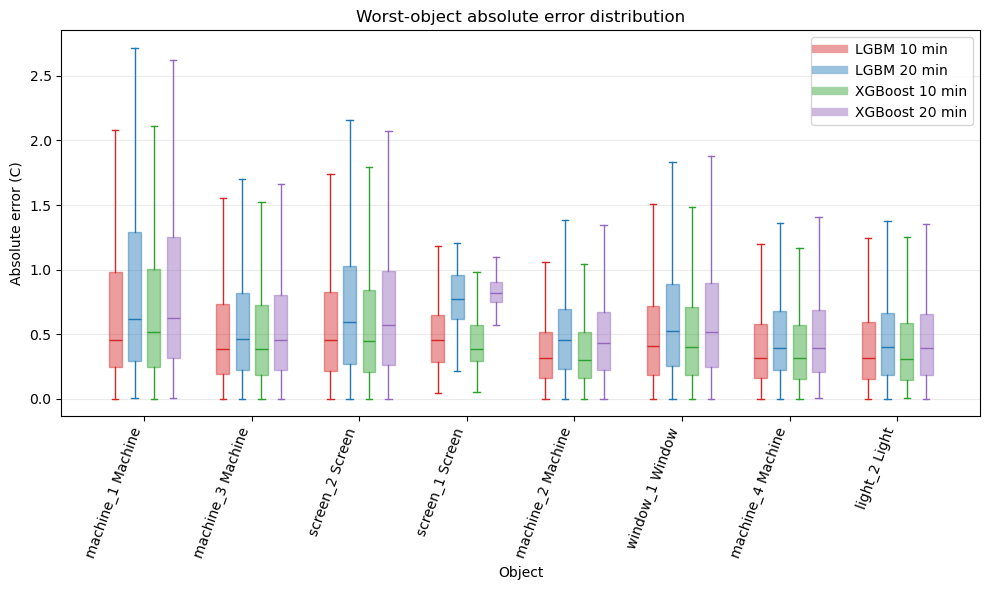

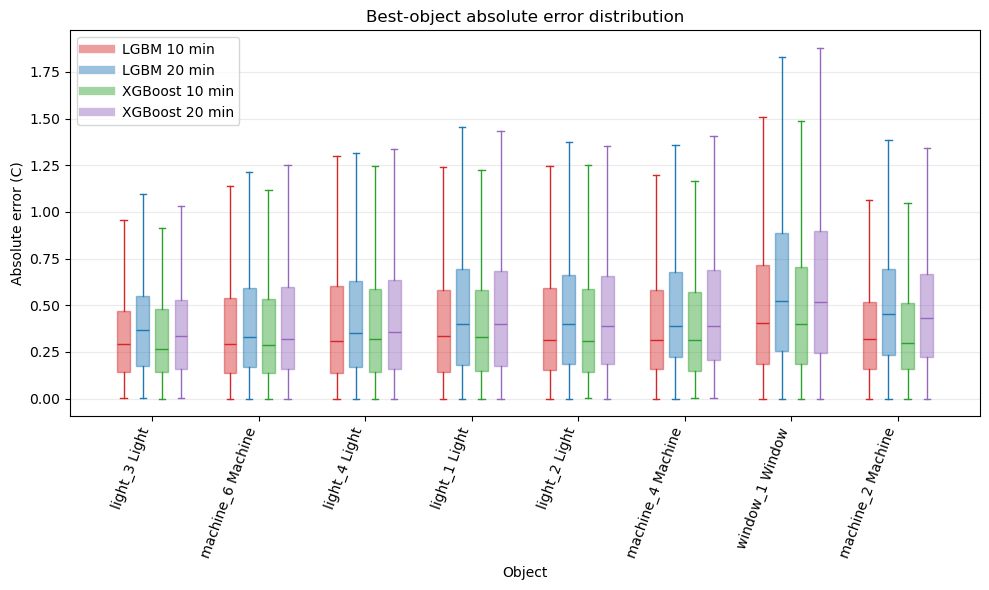

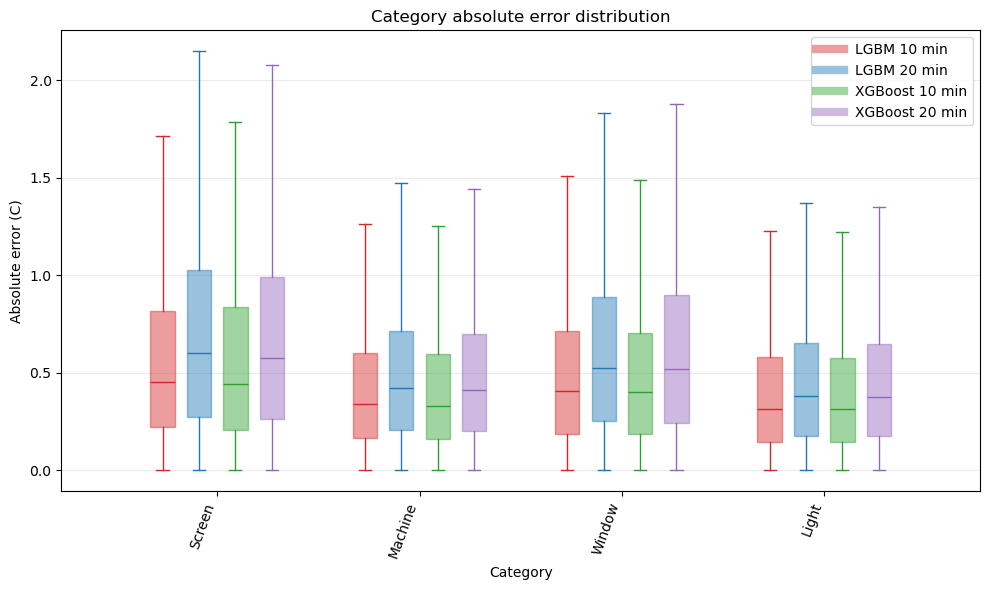

In [19]:
N_OBJECTS_TO_COMPARE = 8
object_metrics = metric_summary(tuned_test_predictions, ['model', 'target_minutes', 'horizon', 'object_id', 'label'])
object_rank = (
    object_metrics
    .groupby(['object_id', 'label'], as_index=False)['rmse']
    .mean()
    .sort_values('rmse', ascending=False)
)
display(object_rank)

plot_errors = tuned_test_predictions.copy()
plot_errors['absolute_error'] = plot_errors['error'].abs()
plot_errors['object_label'] = plot_errors['object_id'].astype(str) + ' ' + plot_errors['label'].astype(str)
series_order = [(model_name, float(target_minutes)) for model_name in MODEL_ORDER for target_minutes in TARGET_MINUTES_LIST]


def plot_absolute_error_boxplot(group_column, group_order, title, xlabel):
    offsets = np.linspace(-0.27, 0.27, len(series_order))
    base_positions = np.arange(len(group_order))
    fig, ax = plt.subplots(figsize=(max(10.0, len(group_order) * 1.25), 6.0))
    legend_handles = []

    for offset, (model_name, target_minutes) in zip(offsets, series_order):
        data = []
        positions = []
        for base_pos, group_value in zip(base_positions, group_order):
            part = plot_errors[
                (plot_errors[group_column] == group_value)
                & (plot_errors['model'] == model_name)
                & (plot_errors['target_minutes'] == target_minutes)
            ]
            if part.empty:
                continue
            data.append(part['absolute_error'].to_numpy())
            positions.append(base_pos + offset)
        if not data:
            continue
        color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
        box = ax.boxplot(data, positions=positions, widths=0.12, patch_artist=True, showfliers=False)
        for patch in box['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.45)
            patch.set_edgecolor(color)
        for element in ['whiskers', 'caps', 'medians']:
            for item in box[element]:
                item.set_color(color)
        legend_handles.append(
            plt.Line2D([0], [0], color=color, linewidth=6, alpha=0.45, label=f'{model_name} {target_minutes:g} min')
        )

    ax.set_xticks(base_positions)
    ax.set_xticklabels(group_order, rotation=70, ha='right')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Absolute error (C)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(handles=legend_handles, loc='best')
    fig.tight_layout()


worst_object_labels = [
    f"{str(row.object_id)} {str(row.label)}"
    for row in object_rank.head(N_OBJECTS_TO_COMPARE).itertuples()
]
best_object_labels = [
    f"{str(row.object_id)} {str(row.label)}"
    for row in object_rank.tail(N_OBJECTS_TO_COMPARE).sort_values('rmse').itertuples()
]
category_order = (
    metric_summary(tuned_test_predictions, ['label'])
    .sort_values('rmse', ascending=False)['label']
    .astype(str)
    .tolist()
)

plot_absolute_error_boxplot('object_label', worst_object_labels, 'Worst-object absolute error distribution', 'Object')
plot_absolute_error_boxplot('object_label', best_object_labels, 'Best-object absolute error distribution', 'Object')
plot_absolute_error_boxplot('label', category_order, 'Category absolute error distribution', 'Category')


## Prediction Timeline

This section plots tuned predictions over time for each object and date, and saves all generated timeline figures.

Ground truth is shown with a rolling mean for visual readability. The y-axis scale is fixed across figures so temperature levels can be compared between objects and dates. A small sample of figures is displayed in the notebook preview.


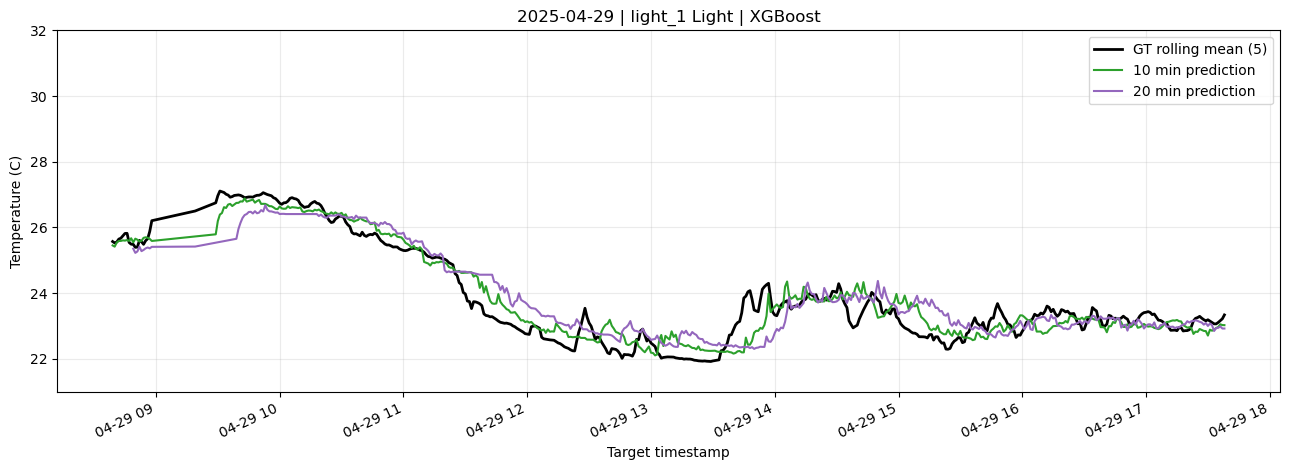

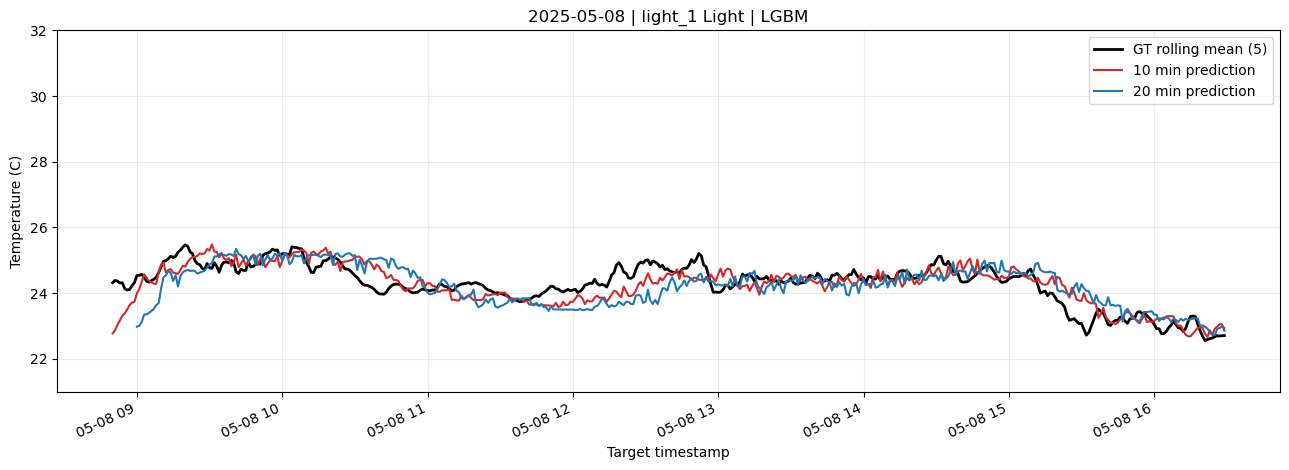

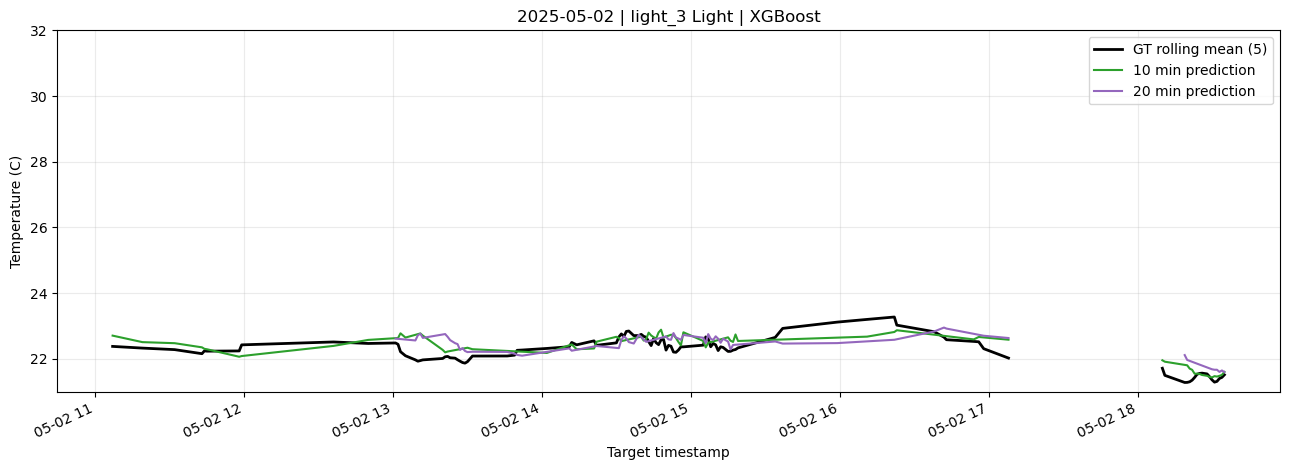

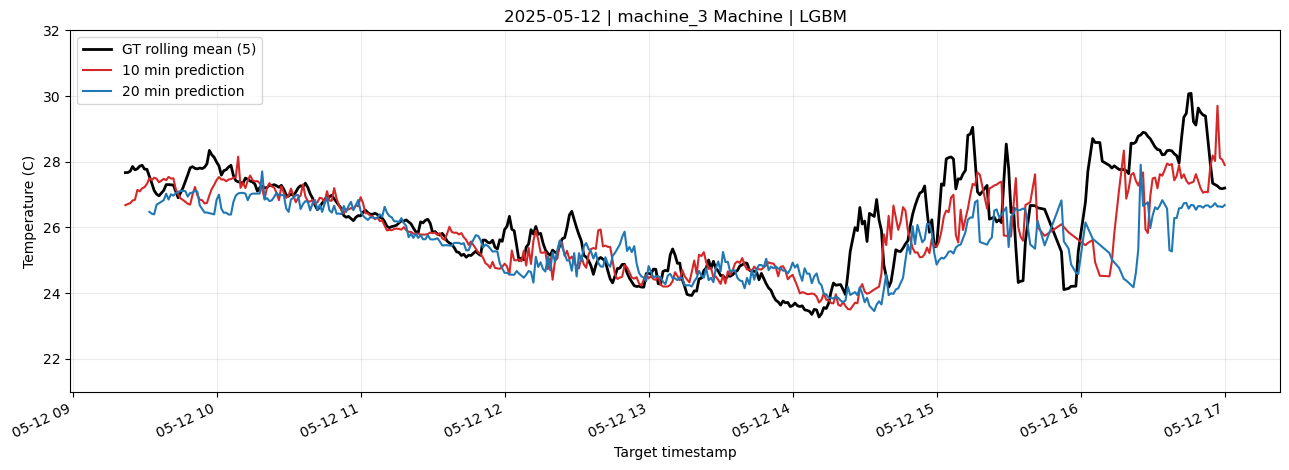

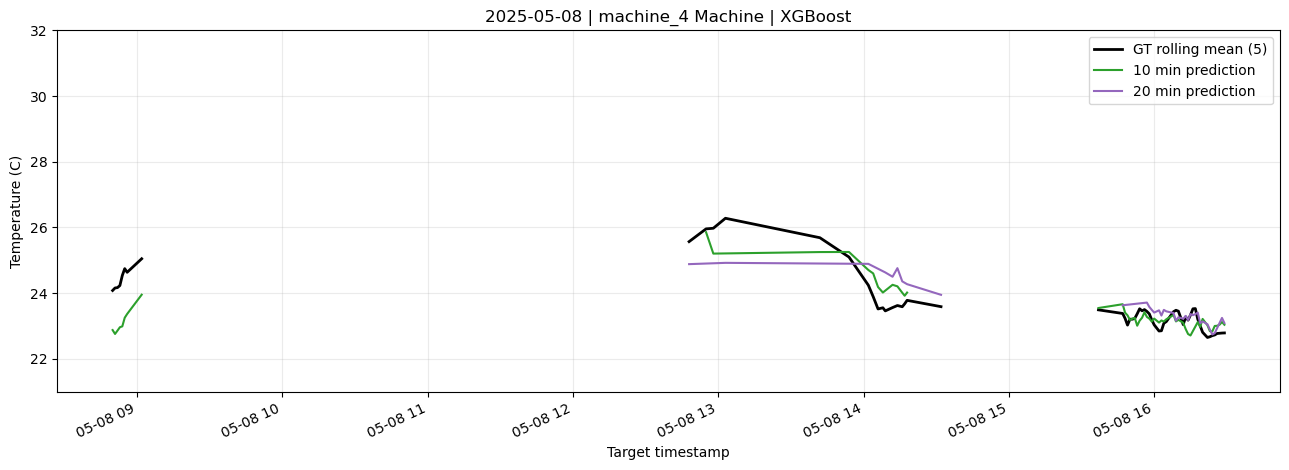

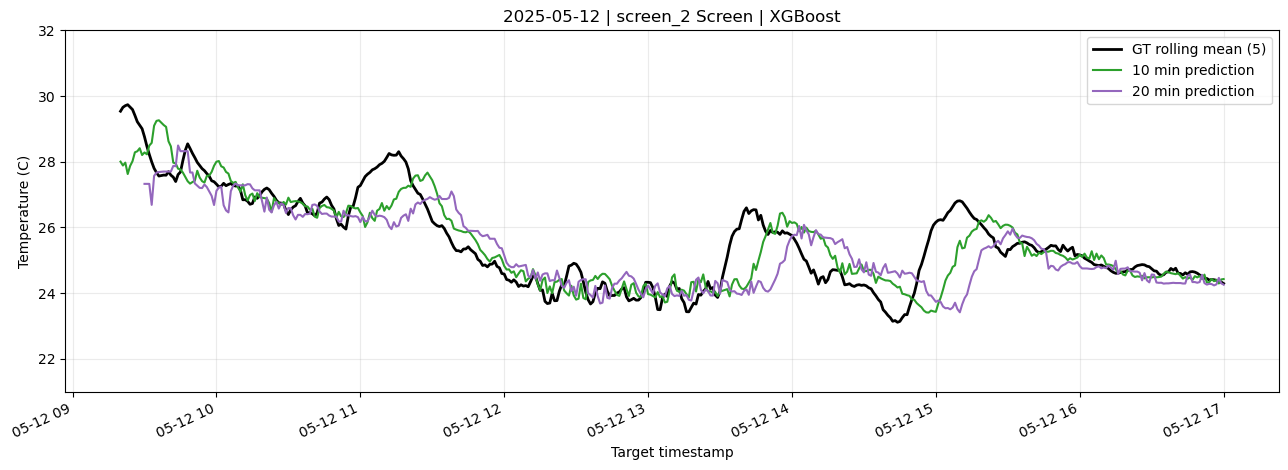

saved timeline figures: 88


,object_id,label,target_date,model,output_png
0,light_1,Light,2025-04-29,LGBM,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
1,light_1,Light,2025-04-29,XGBoost,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
2,light_1,Light,2025-05-02,LGBM,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
3,light_1,Light,2025-05-02,XGBoost,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
4,light_1,Light,2025-05-08,LGBM,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
5,light_1,Light,2025-05-08,XGBoost,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
6,light_1,Light,2025-05-12,LGBM,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
7,light_1,Light,2025-05-12,XGBoost,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
8,light_2,Light,2025-04-29,LGBM,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
9,light_2,Light,2025-04-29,XGBoost,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...


In [20]:
TIMELINE_OBJECT_IDS = sorted(tuned_test_predictions['object_id'].dropna().unique())
GT_SMOOTH_WINDOW = 5
MAX_LINE_GAP_MINUTES = 60.0
TIMELINE_PREVIEW_COUNT = 6
TIMELINE_OUTPUT_DIR = FIGURE_OUTPUT_DIR
TIMELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def safe_plot_name(value):
    return ''.join(ch if ch.isalnum() or ch in ('_', '-') else '_' for ch in str(value)).strip('_')


def add_plot_segments(df, time_col, max_gap_minutes):
    df = df.sort_values(time_col).copy()
    gap = df[time_col].diff().dt.total_seconds().div(60)
    return df.assign(_plot_segment=gap.gt(max_gap_minutes).fillna(False).cumsum())


def smooth_gt(df, value_col='target_temp', output_col='target_temp_plot', window=5):
    df = df.sort_values('target_timestamp').copy()
    df[output_col] = df[value_col].rolling(window=window, center=True, min_periods=1).mean()
    return df


plot_df = tuned_test_predictions.copy()
plot_df['target_timestamp'] = pd.to_datetime(plot_df['target_timestamp'])

plot_tasks = []
for object_id in TIMELINE_OBJECT_IDS:
    object_df = plot_df[plot_df['object_id'] == object_id].copy()
    for target_date, day_df in object_df.groupby(object_df['target_timestamp'].dt.date):
        for model_name, model_day in day_df.groupby('model'):
            plot_tasks.append((object_id, target_date, model_name, day_df, model_day))

rng = np.random.default_rng(RANDOM_STATE)
preview_indices = set(rng.choice(len(plot_tasks), size=min(TIMELINE_PREVIEW_COUNT, len(plot_tasks)), replace=False).tolist()) if plot_tasks else set()
saved_timeline_rows = []

for plot_index, (object_id, target_date, model_name, day_df, model_day) in enumerate(plot_tasks):
    label = str(day_df['label'].mode().iloc[0]) if not day_df['label'].mode().empty else ''
    gt_df = (
        day_df[['target_timestamp', 'target_temp']]
        .drop_duplicates()
        .groupby('target_timestamp', as_index=False)['target_temp']
        .median()
    )
    gt_df = smooth_gt(gt_df, window=GT_SMOOTH_WINDOW)
    gt_df = add_plot_segments(gt_df, 'target_timestamp', MAX_LINE_GAP_MINUTES)

    fig, ax = plt.subplots(figsize=(13, 4.8))
    for segment_id, segment in gt_df.groupby('_plot_segment'):
        ax.plot(
            segment['target_timestamp'],
            segment['target_temp_plot'],
            color='black',
            linewidth=2.0,
            label=f'GT rolling mean ({GT_SMOOTH_WINDOW})' if segment_id == gt_df['_plot_segment'].min() else None,
        )
    for target_minutes, part in model_day.groupby('target_minutes'):
        part = (
            part.groupby('target_timestamp', as_index=False)
            .agg(prediction=('prediction', 'median'))
            .sort_values('target_timestamp')
        )
        part = add_plot_segments(part, 'target_timestamp', MAX_LINE_GAP_MINUTES)
        first_segment = part['_plot_segment'].min()
        for segment_id, segment in part.groupby('_plot_segment'):
            ax.plot(
                segment['target_timestamp'],
                segment['prediction'],
                color=MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777'),
                linewidth=1.5,
                label=f'{target_minutes:g} min prediction' if segment_id == first_segment else None,
            )

    timeline_ylim = TIMELINE_YLIM_BY_LABEL.get(label, TIMELINE_DEFAULT_YLIM)
    if timeline_ylim is not None:
        ax.set_ylim(*timeline_ylim)
    ax.set_title(f'{target_date} | {object_id} {label} | {model_name}')
    ax.set_xlabel('Target timestamp')
    ax.set_ylabel('Temperature (C)')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    fig.autofmt_xdate(rotation=25)
    fig.tight_layout()

    output_png = TIMELINE_OUTPUT_DIR / f"timeline_{target_date}_{safe_plot_name(object_id)}_{safe_plot_name(model_name)}.png"
    fig.savefig(output_png, dpi=160)
    saved_timeline_rows.append({
        'object_id': object_id,
        'label': label,
        'target_date': target_date,
        'model': model_name,
        'output_png': str(output_png),
    })
    if plot_index in preview_indices:
        display(fig)
    plt.close(fig)

saved_timeline_table = pd.DataFrame(saved_timeline_rows)
print(f'saved timeline figures: {len(saved_timeline_table):,}')
display(saved_timeline_table.head(20))
